# 优化 Newton 法的局部二次收敛

考虑严格凸函数

$$f(x,y)=e^x-x+e^{2y}-2y,$$

其唯一最小值点为 $x^*=(0,0)$。实验记录 Newton 迭代轨迹、梯度范数和误差平方比。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib
configure_matplotlib()
from scipy.linalg import solve
from scipy.optimize import minimize

def objective(point):
    x, y = point
    return np.exp(x) - x + np.exp(2.0 * y) - 2.0 * y

def gradient(point):
    x, y = point
    return np.array([np.exp(x) - 1.0, 2.0 * np.exp(2.0 * y) - 2.0])

def hessian(point):
    x, y = point
    return np.diag([np.exp(x), 4.0 * np.exp(2.0 * y)])

start = np.array([1.5, 0.75])
verification = minimize(objective, start, jac=gradient, method="BFGS", tol=1e-13)
print("SciPy verification point:", verification.x)
print("Theoretical minimizer: [0. 0.]")

Matplotlib is building the font cache; this may take a moment.


SciPy verification point: [ 3.51528465e-14 -7.89814117e-15]
Theoretical minimizer: [0. 0.]


In [2]:
def newton_history(x0, maximum_iterations=12, tolerance=1e-14):
    point = np.asarray(x0, dtype=float)
    history = [point.copy()]
    for _ in range(maximum_iterations):
        step = solve(hessian(point), gradient(point), assume_a="pos")
        point = point - step
        history.append(point.copy())
        if np.linalg.norm(gradient(point)) <= tolerance:
            break
    return np.asarray(history)

history = newton_history(start)
errors = np.linalg.norm(history, axis=1)
gradient_norms = np.asarray([np.linalg.norm(gradient(point)) for point in history])

print("k        x_k                 y_k             ||x_k-x*||       ||grad f(x_k)||")
for k, (point, error, grad_norm) in enumerate(zip(history, errors, gradient_norms)):
    print(f"{k:>2d}  {point[0]:>18.10e}  {point[1]:>18.10e}  {error:>14.6e}  {grad_norm:>14.6e}")

print("\nSquared-error ratio ||e_(k+1)|| / ||e_k||^2:")
for k in range(len(errors) - 1):
    if errors[k] > 0:
        print(f"k={k}: {errors[k + 1] / errors[k]**2:.6e}")

k        x_k                 y_k             ||x_k-x*||       ||grad f(x_k)||
 0    1.5000000000e+00    7.5000000000e-01    1.677051e+00    7.785293e+00
 1    7.2313016015e-01    3.6156508007e-01    8.084841e-01    2.372186e+00
 2    2.0836118568e-01    1.0418059284e-01    2.329549e-01    5.180029e-01
 3    2.0274917814e-02    1.0137458907e-02    2.266805e-02    4.579881e-02
 4    2.0415408242e-04    1.0207704121e-04    2.282512e-04    4.565490e-04
 5    2.0838026512e-08    1.0419013256e-08    2.329762e-08    4.659524e-08
 6    3.0837457679e-16    1.5418728840e-16    3.447733e-16    4.965068e-16

Squared-error ratio ||e_(k+1)|| / ||e_k||^2:
k=0: 2.874610e-01
k=1: 3.563928e-01
k=2: 4.177058e-01
k=3: 4.442064e-01
k=4: 4.471832e-01
k=5: 6.351999e-01


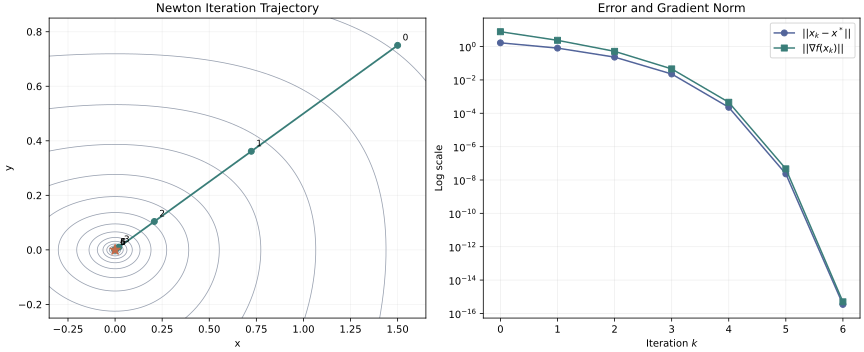

In [3]:
x_grid = np.linspace(-0.35, 1.65, 320)
y_grid = np.linspace(-0.25, 0.85, 320)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.exp(X) - X + np.exp(2.0 * Y) - 2.0 * Y

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), constrained_layout=True)

levels = 2.0 + np.geomspace(1e-4, 8.0, 16)
axes[0].contour(X, Y, Z, levels=levels, colors="#9aa2b1", linewidths=0.8)
axes[0].plot(history[:, 0], history[:, 1], "o-", color="#397d78", linewidth=1.8)
axes[0].scatter([0.0], [0.0], marker="*", s=120, color="#c26b4a", zorder=4)
for k, point in enumerate(history):
    axes[0].annotate(str(k), point, xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[0].set(
    title="Newton Iteration Trajectory",
    xlabel="x",
    ylabel="y",
)
axes[0].grid(alpha=0.15)

tiny = np.finfo(float).tiny
iterations = np.arange(len(history))
axes[1].semilogy(iterations, np.maximum(errors, tiny), "o-", color="#52649a", label=r"$||x_k-x^*||$")
axes[1].semilogy(iterations, np.maximum(gradient_norms, tiny), "s-", color="#397d78", label=r"$||\nabla f(x_k)||$")
axes[1].set(
    title="Error and Gradient Norm",
    xlabel="Iteration $k$",
    ylabel="Log scale",
)
axes[1].grid(True, which="both", alpha=0.2)
axes[1].legend()
plt.show()

## 观察

当迭代点进入最小值邻域后，误差平方比趋于有限常数，误差曲线迅速下降。这对应 Newton 法的局部 Q-二次收敛。